# 05 — Router: solo Fase 3 (profesor)

Notebook mínimo para entrenar el **VisionRouter** con el flujo del profesor: **logits del experto congelado × gating del router** y pérdida de tarea (`L_task`) + `L_aux`, **sin** ablation, **sin** pruebas dummy, **sin** validación de etiquetas, **sin** warm-up ni fase de partial-unfreeze previa.

**Datos:** misma **Fase 1** que el notebook `03`: ZIPs en `RAW_DIR` (Drive) → descompresión en `LOCAL_DEST` (`/content/datasets/`). Si ya tienes las carpetas descomprimidas, puedes poner `RUN_EXTRACT_ZIPS = False`.

**Expertos:** checkpoints en `WEIGHTS_DIR` (mismos candidatos que en el notebook 03).

**Validación:** embeddings CLS en validación (cache `.npz` o extracción automática la primera vez).


In [4]:
!pip install -q SimpleITK nibabel torch torchvision monai einops timm
import os
import glob
import random
import shutil
import subprocess
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
import SimpleITK as sitk
import nibabel as nib
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models.video import R3D_18_Weights, r3d_18
from torch.utils.checkpoint import checkpoint as grad_checkpoint
from monai.networks.blocks import PatchEmbed
import timm
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# --- Rutas (igual que notebook 03): ZIPs en Drive → datasets en disco local Colab ---
RAW_DIR = "/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/"
LOCAL_DEST = "/content/datasets/"
WEIGHTS_DIR = "/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/"
FEATURE_DIR = WEIGHTS_DIR
os.makedirs(LOCAL_DEST, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

DATASET_ROOTS = {
    "NIH":      (os.path.join(LOCAL_DEST, "NIH Chest X ray 14"), 0),
    "ISIC":     (os.path.join(LOCAL_DEST, "ISIC 2019"), 1),
    "Osteo":    (os.path.join(LOCAL_DEST, "Knee Osteoarthritis Classification"), 2),
    "LUNA16":   (os.path.join(LOCAL_DEST, "Luna16_ROI_cache_v1"), 3),
    "Pancreas": (os.path.join(LOCAL_DEST, "Pancreas Cancer"), 4),
}

print("Rutas (datasets tras extracción en LOCAL_DEST):")
for k, (p, d) in DATASET_ROOTS.items():
    ok = os.path.isdir(p)
    print(f"  {k} id={d} exists={ok} -> {p}")
print(f"RAW_DIR={RAW_DIR}")
print(f"LOCAL_DEST={LOCAL_DEST}")
print(f"WEIGHTS_DIR={WEIGHTS_DIR}")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rutas (datasets tras extracción en LOCAL_DEST):
  NIH id=0 exists=True -> /content/datasets/NIH Chest X ray 14
  ISIC id=1 exists=True -> /content/datasets/ISIC 2019
  Osteo id=2 exists=True -> /content/datasets/Knee Osteoarthritis Classification
  LUNA16 id=3 exists=True -> /content/datasets/Luna16 Lung Cancer Dataset
  Pancreas id=4 exists=True -> /content/datasets/Pancreas Cancer
RAW_DIR=/content/drive/MyDrive/PROYECTO_MOE_VISION/01_Data/Raw/
LOCAL_DEST=/content/datasets/
WEIGHTS_DIR=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/


## Fase 1: Extracción de datos a disco local

Copia los `.zip` desde `RAW_DIR` (Google Drive) a `LOCAL_DEST` y los descomprime. **Misma lógica que `03_Pipeline_Router_MoE.ipynb`.**

Pon `RUN_EXTRACT_ZIPS = False` si las carpetas de datasets ya existen en `/content/datasets/`.


In [5]:
def extract_datasets_colab(raw_dir=RAW_DIR, local_dest=LOCAL_DEST):
    """Copia ZIPs de Drive a /content/datasets/ y los descomprime (notebook 03)."""
    if not os.path.exists(raw_dir):
        print(f"Ruta {raw_dir} no existe. No se extrae nada.")
        return
    zip_files = sorted([f for f in os.listdir(raw_dir) if f.lower().endswith(".zip")])
    print(f"Encontrados {len(zip_files)} zips.")
    for zip_name in zip_files:
        print("=" * 60)
        print(f"Procesando: {zip_name}")
        drive_zip_path = os.path.join(raw_dir, zip_name)
        dataset_name = os.path.splitext(zip_name)[0]
        unzip_dir = os.path.join(local_dest, dataset_name)
        local_zip_path = os.path.join(local_dest, zip_name)
        if os.path.isdir(unzip_dir) and len(os.listdir(unzip_dir)) > 0:
            print(f" Ya existe: {unzip_dir} (omitido).")
            continue
        print(" 1. Copiando ZIP...")
        shutil.copy2(drive_zip_path, local_zip_path)
        os.makedirs(unzip_dir, exist_ok=True)
        print(f" 2. Descomprimiendo en {unzip_dir}...")
        subprocess.run(["unzip", "-q", local_zip_path, "-d", unzip_dir], check=True)
        print(" 3. Borrando ZIP local.")
        os.remove(local_zip_path)
        # ZIPs internos
        for iz in glob.glob(os.path.join(unzip_dir, "**", "*.zip"), recursive=True):
            print(f" -> ZIP interno: {iz}")
            subprocess.run(["unzip", "-q", iz, "-d", os.path.dirname(iz)], check=True)
            os.remove(iz)
    print("\nExtracción completa.")


RUN_EXTRACT_ZIPS = True  # False si ya descomprimiste en esta sesión
if RUN_EXTRACT_ZIPS:
    extract_datasets_colab()
else:
    print("RUN_EXTRACT_ZIPS=False: se asume que LOCAL_DEST ya contiene los datasets.")


Encontrados 5 zips.
Procesando: ISIC 2019.zip
 Ya existe: /content/datasets/ISIC 2019 (omitido).
Procesando: Knee Osteoarthritis Classification.zip
 Ya existe: /content/datasets/Knee Osteoarthritis Classification (omitido).
Procesando: Luna16 Lung Cancer Dataset.zip
 Ya existe: /content/datasets/Luna16 Lung Cancer Dataset (omitido).
Procesando: NIH Chest X ray 14.zip
 Ya existe: /content/datasets/NIH Chest X ray 14 (omitido).
Procesando: Pancreas Cancer.zip
 Ya existe: /content/datasets/Pancreas Cancer (omitido).

Extracción completa.


In [6]:
# =============================================================================
# Arquitecturas de los 5 expertos (embebido en el notebook; sin .py externo)
# =============================================================================

import os
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import timm
import torchvision.models as models
from torchvision.models.video import R3D_18_Weights, r3d_18


# ============================================================================
# Experto 1 (NIH) - Swin-Tiny (NIH_ChestXray_Swin_Tiny_Training.ipynb)
# 5 clases multietiqueta (Mass, Nodule, Effusion, Cardiomegaly, Pneumothorax).
# Pesos: suele guardarse como Experts_2D/MaxViT_NIH_5cls.pth (nombre historico en CONFIG).
# ============================================================================
class SwinNIHClassifier(nn.Module):
    """Misma envoltura que SwinClassifier en el notebook de entrenamiento (timm)."""

    def __init__(self, num_classes: int = 5, pretrained: bool = True):
        super().__init__()
        self.model = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=num_classes,
        )

    def forward(self, x):
        return self.model(x)


# ============================================================================
# Experto 3 (Osteo) - VGG16-BN
# ============================================================================
def build_vgg16_bn(num_classes: int = 5, pretrained: bool = True):
    model = models.vgg16_bn(weights="IMAGENET1K_V1" if pretrained else None)
    old_conv = model.features[0]
    new_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)
    with torch.no_grad():
        new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        new_conv.bias.copy_(old_conv.bias)
    model.features[0] = new_conv
    model.classifier = nn.Sequential(
        nn.Linear(512 * 7 * 7, 512),
        nn.ReLU(True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(True),
        nn.BatchNorm1d(256),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model


# ============================================================================
# Experto 4 (LUNA16 3D) - DCSwinBStyle3D (igual a LUNA16_Swin3D_Training.ipynb)
# Experto 5 (Pancreas 3D) - R3D18
# ============================================================================
from torch.utils.checkpoint import checkpoint as grad_checkpoint


class DCSwinBStyle3D(nn.Module):
    """Dual-branch estilo DCSwinB: Swin-Tiny 3D (inflate timm) + CNN 3D (stem+layer1+layer2 de R3D-18)."""

    def __init__(self, num_classes: int = 2, pretrained: bool = True, use_dwconv_mix: bool = True):
        super().__init__()
        self.use_dwconv_mix = use_dwconv_mix

        swin2d = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=pretrained,
            num_classes=0,
            img_size=256,
        )
        old_proj = swin2d.patch_embed.proj
        c_out = old_proj.out_channels

        self.patch_embed_3d = nn.Conv3d(1, c_out, kernel_size=(4, 4, 4), stride=(4, 4, 4), padding=0)
        w2d = old_proj.weight.data
        w_mean = w2d.mean(dim=1, keepdim=True)
        w3d = w_mean.unsqueeze(2).expand(-1, -1, 4, -1, -1) / 4.0
        with torch.no_grad():
            self.patch_embed_3d.weight.copy_(w3d)
            if old_proj.bias is not None and self.patch_embed_3d.bias is not None:
                self.patch_embed_3d.bias.copy_(old_proj.bias.data)

        if use_dwconv_mix:
            self.dw_mix = nn.Conv3d(c_out, c_out, 3, padding=1, groups=c_out, bias=True)
            nn.init.zeros_(self.dw_mix.weight)
            if self.dw_mix.bias is not None:
                nn.init.zeros_(self.dw_mix.bias)
        else:
            self.dw_mix = None

        self.patch_embed_norm = swin2d.patch_embed.norm
        self.layers = swin2d.layers
        self.norm = swin2d.norm
        self.swin_dim = swin2d.num_features
        del swin2d

        w = R3D_18_Weights.DEFAULT if pretrained else None
        base = r3d_18(weights=w)
        oc = base.stem[0]
        conv1 = nn.Conv3d(1, 64, kernel_size=oc.kernel_size, stride=oc.stride, padding=oc.padding, bias=False)
        with torch.no_grad():
            conv1.weight.copy_(oc.weight.mean(dim=1, keepdim=True))

        self.cnn_branch = nn.Sequential(
            conv1,
            base.stem[1],
            base.stem[2],
            base.layer1,
            base.layer2,
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten(),
        )
        self.cnn_dim = 128
        del base

        self.head = nn.Linear(self.swin_dim + self.cnn_dim, num_classes)
        self.num_features = self.swin_dim + self.cnn_dim

    def forward(self, x):
        z_cnn = self.cnn_branch(x)
        t = self.patch_embed_3d(x)
        if self.dw_mix is not None:
            t = t + self.dw_mix(t)
        b, c, d, h, w = t.shape
        t = t.view(b, c, 4, 4, h, w)
        t = t.permute(0, 1, 2, 4, 3, 5)
        t = t.reshape(b, c, 4 * h, 4 * w)
        t = t.permute(0, 2, 3, 1)
        t = self.patch_embed_norm(t)
        for layer in self.layers:
            t = grad_checkpoint(layer, t, use_reentrant=False)
        t = self.norm(t)
        z_swin = t.mean(dim=[1, 2])
        z = torch.cat([z_swin, z_cnn], dim=1)
        return self.head(z)


class R3D18Expert(nn.Module):
    """R3D-18 para 3D binario (usado por Exp5 Pancreas; y plan B para Exp4 si hiciera falta)."""

    def __init__(self, num_classes: int = 2, pretrained: bool = True):
        super().__init__()
        weights = R3D_18_Weights.DEFAULT if pretrained else None
        base = r3d_18(weights=weights)
        old_conv = base.stem[0]
        stem_conv = nn.Conv3d(
            1,
            64,
            kernel_size=(3, 7, 7),
            stride=(1, 2, 2),
            padding=(1, 3, 3),
            bias=False,
        )
        with torch.no_grad():
            stem_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        base.stem[0] = stem_conv
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head = nn.Linear(512, num_classes)

    def forward(self, x):
        # Gradient checkpointing obligatorio para expertos 3D (consigna §8.1)
        for block in self.backbone:
            x = grad_checkpoint(block, x, use_reentrant=False)
        return self.head(x.flatten(1))


# ============================================================================
# Factory y carga de pesos
# ============================================================================
import glob
import subprocess

EXPERT_SPECS = {
    1: {"name": "exp1_nih", "num_classes": 5, "arch": "swin_tiny_nih"},
    2: {"name": "exp2_isic", "num_classes": 9, "arch": "efficientnet_b3"},
    3: {"name": "exp3_osteo", "num_classes": 5, "arch": "vgg16_bn"},
    4: {"name": "exp4_luna16", "num_classes": 2, "arch": "dcswinb3d"},
    5: {"name": "exp5_pancreas", "num_classes": 2, "arch": "r3d18"},
}


def build_expert(expert_id: int, pretrained_backbone: bool = True):
    spec = EXPERT_SPECS[int(expert_id)]
    arch = spec["arch"]
    num_classes = spec["num_classes"]

    if arch == "swin_tiny_nih":
        return SwinNIHClassifier(num_classes=num_classes, pretrained=pretrained_backbone)
    if arch == "efficientnet_b3":
        return timm.create_model("efficientnet_b3", pretrained=pretrained_backbone, num_classes=num_classes)
    if arch == "vgg16_bn":
        return build_vgg16_bn(num_classes=num_classes, pretrained=pretrained_backbone)
    if arch == "dcswinb3d":
        # En entrenamiento original: pretrained=True para timm/torchvision.
        # Al cargar checkpoint, pretrained_backbone puede ser False (los pesos vienen del ckpt).
        return DCSwinBStyle3D(num_classes=num_classes, pretrained=pretrained_backbone)
    if arch == "r3d18":
        return R3D18Expert(num_classes=num_classes, pretrained=pretrained_backbone)
    raise ValueError(f"Arquitectura no soportada: {arch}")


def _default_checkpoint_candidates(weights_dir: str) -> Dict[int, List[str]]:
    """
    Candidatos por experto para tolerar nombres antiguos/nuevos de checkpoints.
    """
    return {
        1: [
            os.path.join(weights_dir, "Experts_2D", "Swin_NIH_5cls.pth"),
            os.path.join(weights_dir, "exp1_NIH_Swin_Tiny_best.pth"),
            
            os.path.join(weights_dir, "exp1_NIH_SwinTiny_best.pth"),
            
        ],
        2: [
            os.path.join(weights_dir, "exp2_ISIC_EfficientNetB3_best.pth"),
        ],
        3: [
            os.path.join(weights_dir, "exp3_Osteo_VGG16BN_best.pth"),
        ],
        4: [
            # Ruta real del Experto 4 en LUNA16_Swin3D_Training.ipynb
            os.path.join(weights_dir, "Experts_2D", "Expert4_LUNA16", "checkpoints", "expert4_*_best.pth"),
            # Legacy opcional (si alguna vez exportaste así)
            os.path.join(weights_dir, "exp4_LUNA16_3D_best.pth"),
        ],
        5: [
            os.path.join(weights_dir, "exp5_Pancreas_3D_best.pth"),
            os.path.join(weights_dir, "r3d18_pancreas_best_V2.pth"),
        ],
    }


def resolve_checkpoint(candidates: List[str]) -> str:
    """
    Busca el checkpoint. Si existe ``<ruta>.pth.zip`` y no el ``.pth``,
    descomprime en el mismo directorio y devuelve la ruta del ``.pth``.
    """
    for p in candidates:
        if any(ch in p for ch in ["*", "?", "["]):
            matches = sorted(glob.glob(p))
            if matches:
                return matches[0]
        if os.path.exists(p):
            return p
        zip_path = p + ".zip"
        if os.path.exists(zip_path):
            print(f"📦 Detectado peso comprimido: {os.path.basename(zip_path)}")
            extract_dir = os.path.dirname(zip_path) or "."
            try:
                print(f"  → Descomprimiendo en {extract_dir}...")
                subprocess.run(["unzip", "-o", zip_path, "-d", extract_dir], check=True)
                if os.path.exists(p):
                    print(f"  ✅ Checkpoint extraído: {os.path.basename(p)}")
                    return p
                new_matches = glob.glob(os.path.join(extract_dir, os.path.basename(p)))
                if new_matches:
                    return sorted(new_matches)[0]
            except Exception as e:
                print(f"  ❌ Error al descomprimir {zip_path}: {e}")
    return ""


def load_weights(model: nn.Module, ckpt_path: str, map_location: str = "cpu", strict: bool = False):
    if not ckpt_path or not os.path.exists(ckpt_path):
        return False, "checkpoint no encontrado"
    raw = torch.load(ckpt_path, map_location=map_location)

    # Checkpoints de entrenamiento suelen ser dict con 'state_dict'
    if isinstance(raw, dict):
        if "state_dict" in raw:
            state = raw["state_dict"]
        elif "model_state_dict" in raw:
            state = raw["model_state_dict"]
        elif "model" in raw and isinstance(raw["model"], dict):
            state = raw["model"]
        else:
            state = raw
    else:
        state = raw

    try:
        model.load_state_dict(state, strict=strict)
        return True, "ok"
    except Exception as e:
        return False, f"load_state_dict fallo: {e}"

def freeze_and_eval(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    return model


def load_all_experts_from_drive(
    weights_dir: str,
    device: str = "cpu",
    strict: bool = False,
    pretrained_backbone: bool = False,
) -> Tuple[Dict[int, nn.Module], Dict[int, dict]]:
    """
    Crea y carga los 5 expertos con pesos desde Drive.

    Retorna:
      experts: dict[int, nn.Module]
      info: dict[int, {arch, ckpt, loaded, params}]
    """
    candidates = _default_checkpoint_candidates(weights_dir)
    experts = {}
    info = {}

    for eid in sorted(EXPERT_SPECS.keys()):
        model = build_expert(eid, pretrained_backbone=pretrained_backbone)
        ckpt_path = resolve_checkpoint(candidates[eid])
        loaded, msg = load_weights(model, ckpt_path, map_location="cpu", strict=strict)

        # Si Exp4 fue entrenado con plan B (R3D18) pero spec pide DCSwin, intentar fallback.
        if not loaded and int(eid) == 4:
            fallback = R3D18Expert(num_classes=2, pretrained=pretrained_backbone)
            loaded2, msg2 = load_weights(fallback, ckpt_path, map_location="cpu", strict=strict)
            if loaded2:
                model = fallback
                loaded, msg = loaded2, f"fallback R3D18 OK: {msg2}"

        model = freeze_and_eval(model).to(device)
        experts[eid] = model
        info[eid] = {
            "name": EXPERT_SPECS[eid]["name"],
            "arch": EXPERT_SPECS[eid]["arch"],
            "ckpt": ckpt_path,
            "loaded": loaded,
            "message": msg,
            "params": int(sum(p.numel() for p in model.parameters())),
        }

    return experts, info


def print_expert_load_report(info: Dict[int, dict]):
    print("=== Expert Load Report ===")
    for eid in sorted(info.keys()):
        row = info[eid]
        status = "OK" if row["loaded"] else "MISSING"
        print(
            f"Exp{eid} | {row['name']} | arch={row['arch']} | {status} | "
            f"params={row['params']:,} | ckpt={row['ckpt'] or 'N/A'}"
        )
print("Arquitecturas de expertos: definidas en el notebook.")


Arquitecturas de expertos: definidas en el notebook.


In [7]:

import SimpleITK as sitk

def extract_luna_roi_64(mhd_path, coords_world, size=(64, 64, 64), hu_min=-1000.0, hu_max=400.0):
    """Resample a 1mm e intersecta ROI de 64^3 (LUNA Expert alignment)."""
    try:
        img = sitk.ReadImage(mhd_path)
        orig_spacing = np.array(img.GetSpacing())
        orig_size = np.array(img.GetSize())
        new_spacing = np.array([1.0, 1.0, 1.0])
        new_size = (orig_size * orig_spacing / new_spacing).astype(int).tolist()

        resampler = sitk.ResampleImageFilter()
        resampler.SetOutputSpacing(new_spacing.tolist())
        resampler.SetSize(new_size)
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetOutputOrigin(img.GetOrigin())
        resampler.SetOutputDirection(img.GetDirection())
        img = resampler.Execute(img)

        vol = sitk.GetArrayFromImage(img).astype(np.float32)
        vol = np.clip(vol, hu_min, hu_max)
        vol = (vol - hu_min) / (hu_max - hu_min + 1e-8)

        # Transforma coord mundo a indice en el volumen resampleado
        voxel_coord = img.TransformPhysicalPointToIndex(coords_world)
        cz, cy, cx = voxel_coord[2], voxel_coord[1], voxel_coord[0]

        half = size[0] // 2
        d, h, w = vol.shape
        z0 = max(0, min(d - size[0], cz - half)); z1 = z0 + size[0]
        y0 = max(0, min(h - size[1], cy - half)); y1 = y0 + size[1]
        x0 = max(0, min(w - size[2], cx - half)); x1 = x0 + size[2]

        roi = vol[max(0,z0):z1, max(0,y0):y1, max(0,x0):x1]
        
        # Padding si queda corto
        if roi.shape != size:
            p_d = max(0, size[0] - roi.shape[0])
            p_h = max(0, size[1] - roi.shape[1])
            p_w = max(0, size[2] - roi.shape[2])
            roi = np.pad(roi, ((0, p_d), (0, p_h), (0, p_w)), mode='constant')
        
        return roi[:size[0], :size[1], :size[2]]
    except Exception as e:
        # Fallback: volume resize lento si falla SimpleITK
        return None

class AdaptivePreprocessor:
    """Carga archivos y retorna tensores nativos (2D o 3D). Soporta LUNA ROIs."""
    def __init__(self, size_2d=(224, 224), size_3d=(64, 64, 64), hu_window_ct=(-1000, 400)):
        self.size_2d = size_2d
        self.size_3d = size_3d
        self.hu_min, self.hu_max = hu_window_ct

    def __call__(self, input_val):
        # input_val puede ser string (path) o dict (LUNA candidate)
        if isinstance(input_val, dict):
            return self._process_luna_candidate(input_val)
        
        path = str(input_val)
        ext = path.lower()
        if ext.endswith(('.png', '.jpg', '.jpeg')): return self._process_2d(path)
        if ext.endswith('.mha'):                     return self._process_mha(path)
        if ext.endswith(('.mhd', '.nii.gz', '.nii', '.npz')): return self._process_3d(path)
        raise ValueError(f'Formato no soportado: {path}')

    def _process_luna_candidate(self, cand):
        mhd = cand['mhd_path']
        coords = [cand['x'], cand['y'], cand['z']]
        roi = extract_luna_roi_64(mhd, coords, size=self.size_3d, hu_min=self.hu_min, hu_max=self.hu_max)
        if roi is not None:
            return torch.from_numpy(roi).unsqueeze(0)
        # Fallback: process whole mhd if ROI fails
        return self._process_3d(mhd)

    def _process_2d(self, path):
        img = Image.open(path).convert('RGB')
        transform = T.Compose([T.Resize(self.size_2d), T.ToTensor()])
        return transform(img)

    def _process_mha(self, path):
        itk_img = sitk.ReadImage(path)
        size = itk_img.GetSize()
        arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        if len(size) == 2:                       return self._array_2d_to_tensor(arr)
        if len(size) == 3 and size[2] <= 1:
            arr = np.squeeze(arr)
            if arr.ndim == 2:                    return self._array_2d_to_tensor(arr)
        return self._volume_array_to_tensor(arr, path)

    def _array_2d_to_tensor(self, arr):
        if arr.max() > 1.5:
            arr = arr / 255.0 if arr.max() > 2.0 else (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        t = torch.from_numpy(arr).unsqueeze(0)
        if t.shape[1:] != torch.Size(self.size_2d):
            t = F.interpolate(t.unsqueeze(0), size=self.size_2d, mode='bilinear', align_corners=False).squeeze(0)
        if t.shape[0] == 1:  t = t.repeat(3, 1, 1)
        elif t.shape[0] > 3: t = t[:3]
        return t

    def _volume_array_to_tensor(self, img_arr, path_hint=''):
        amin, amax = float(np.nanmin(img_arr)), float(np.nanmax(img_arr))
        # Pancreas o NPZ ya procesado
        pre_norm = (amax <= 1.5 and amin >= -1e-2) or 'Pancreas' in str(path_hint).replace('\\', '/')
        if not pre_norm:
            img_arr = np.clip(img_arr, self.hu_min, self.hu_max)
            img_arr = (img_arr - self.hu_min) / (self.hu_max - self.hu_min + 1e-8)
        else:
            img_arr = np.clip(img_arr, 0.0, 1.0)
            
        if img_arr.shape == self.size_3d:
            return torch.from_numpy(img_arr).unsqueeze(0)
            
        t = torch.tensor(img_arr, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        t = F.interpolate(t, size=self.size_3d, mode='trilinear', align_corners=False)
        return t.squeeze(0)

    def _process_3d(self, path):
        if path.endswith('.npz'):
            d = np.load(path)
            # Buscar llave de volumen
            k = 'volume' if 'volume' in d else ('Z' if 'Z' in d else list(d.keys())[0])
            img_arr = d[k].astype(np.float32)
            return self._volume_array_to_tensor(img_arr, path_hint=path)
        
        if path.endswith('.mhd'):
            itk_img = sitk.ReadImage(path)
            img_arr = sitk.GetArrayFromImage(itk_img).astype(np.float32)
        else:
            nii_img = nib.load(path)
            img_arr = np.transpose(nii_img.get_fdata().astype(np.float32), (2, 1, 0))
        return self._volume_array_to_tensor(img_arr, path_hint=path)

preprocessor = AdaptivePreprocessor()
print('AdaptivePreprocessor unificado (con soporte ROI LUNA y NPZ) listo.')
        if path.endswith('.npz'):
            d = np.load(path)
            k = 'Z' if 'Z' in d else ('volume' if 'volume' in d else list(d.keys())[0])
            return self._volume_array_to_tensor(d[k].astype(np.float32), path_hint=path)


AdaptivePreprocessor listo.


In [8]:
# =============================================================================
# Filtrado NIH: solo imágenes con al menos una de las 5 clases del Experto 1
# =============================================================================
import pandas as pd

NIH_EXPERT_5_CLASSES = {"Mass", "Nodule", "Effusion", "Cardiomegaly", "Pneumothorax"}


def build_nih_filtered_fileset(nih_root: str) -> set:
    """
    Lee el CSV de NIH y retorna un set con los nombres de archivo (basename)
    que tienen al menos una de las 5 clases del Experto 1.
    Si el CSV no se encuentra, retorna set vacío (sin filtro).
    """
    csv_candidates = glob.glob(os.path.join(nih_root, "**", "*.csv"), recursive=True)
    nih_csv = next(
        (
            c
            for c in csv_candidates
            if "data_entry" in os.path.basename(c).lower() and "2017" in os.path.basename(c).lower()
        ),
        None,
    )
    if nih_csv is None:
        print("  [NIH filter] CSV no encontrado → sin filtro aplicado.")
        return set()

    try:
        df = pd.read_csv(nih_csv)
    except Exception:
        print("  [NIH filter] no se pudo leer el CSV → sin filtro aplicado.")
        return set()
    if "Image Index" not in df.columns or "Finding Labels" not in df.columns:
        print("  [NIH filter] CSV inválido → sin filtro aplicado.")
        return set()

    valid_filenames = set()
    for _, row in df.iterrows():
        labels = {l.strip() for l in str(row["Finding Labels"]).split("|") if l.strip()}
        if labels & NIH_EXPERT_5_CLASSES:
            valid_filenames.add(str(row["Image Index"]))

    print(f"  [NIH filter] {len(valid_filenames):,} imágenes con al menos 1 de {NIH_EXPERT_5_CLASSES}")
    return valid_filenames


print("Filtro NIH (5 clases del Experto 1) definido.")


Filtro NIH (5 clases del Experto 1) definido.


In [9]:

def _infer_label_from_npz(path):
    try:
        d = np.load(path)
        if 'y' in d: return int(d['y'])
        if 'label' in d: return int(d['label'])
    except: pass
    return None

def build_dataset_label_index(roots):
    idx = {'nih': {}, 'isic': {}, 'osteo': {}, 'luna16': {}, 'meta': {}}

    # NIH
    nih_root = roots.get('NIH', (None, None))[0]
    if nih_root and os.path.isdir(nih_root):
        nih_csv = next((c for c in glob.glob(os.path.join(nih_root, '**', '*.csv'), recursive=True) if 'data_entry' in os.path.basename(c).lower()), None)
        if nih_csv:
            df = _safe_read_csv(nih_csv)
            if df is not None:
                for _, r in df.iterrows():
                    idx['nih'][str(r['Image Index'])] = [float(cls in str(r['Finding Labels'])) for cls in NIH_CLASSES_14]

    # ISIC
    isic_root = roots.get('ISIC', (None, None))[0]
    if isic_root and os.path.isdir(isic_root):
        isic_csv = next((c for c in glob.glob(os.path.join(isic_root, '**', '*.csv'), recursive=True) if all(col in pd.read_csv(c, nrows=1).columns for col in ISIC_CLASSES_8)), None)
        if isic_csv:
            df = _safe_read_csv(isic_csv)
            if df is not None:
                img_col = df.columns[0]
                for _, r in df.iterrows():
                    idx['isic'][str(r[img_col])] = int(np.argmax(r[ISIC_CLASSES_8].to_numpy()))

    # Osteo
    osteo_root = roots.get('Osteo', (None, None))[0]
    if osteo_root and os.path.isdir(osteo_root):
        for grade in range(5):
            for f in glob.glob(os.path.join(osteo_root, '**', str(grade), '*.*'), recursive=True):
                if f.lower().endswith(VALID_EXTENSIONS): idx['osteo'][os.path.normpath(f)] = grade

    # LUNA16: Lista de candidatos (ROIs) en lugar de series
    luna_root = roots.get('LUNA16', (None, None))[0]
    if luna_root and os.path.isdir(luna_root):
        cand_csv = next((c for c in glob.glob(os.path.join(luna_root, '**', '*.csv'), recursive=True) if 'candidates' in os.path.basename(c).lower()), None)
        if cand_csv:
            df = _safe_read_csv(cand_csv)
            if df is not None:
                # Mapear seriesuid a ruta mhd real
                mhd_map = {os.path.splitext(os.path.basename(p))[0]: p for p in glob.glob(os.path.join(luna_root, '**', '*.mhd'), recursive=True)}
                candidates_list = []
                for _, r in df.iterrows():
                    suid = str(r['seriesuid'])
                    if suid in mhd_map:
                        candidates_list.append({
                            'mhd_path': mhd_map[suid],
                            'x': float(r['coordX']), 'y': float(r['coordY']), 'z': float(r['coordZ']),
                            'label': int(r['class'])
                        })
                idx['luna16'] = candidates_list
                print(f"  [LUNA16] Cargados {len(candidates_list)} candidatos ROI.")

    return idx

def resolve_task_label(fpath, dataset_id, label_index):
    # fpath puede ser dict para LUNA
    if isinstance(fpath, dict):
        return fpath.get('label')
    
    p = os.path.normpath(fpath)
    fname = os.path.basename(p)
    stem = os.path.splitext(fname)[0]

    if dataset_id == 0: return label_index['nih'].get(fname)
    if dataset_id == 1: return label_index['isic'].get(stem) or label_index['isic'].get(fname)
    if dataset_id == 2: return label_index.get('osteo', {}).get(p) or _infer_osteo_label_from_path(p)
    if dataset_id == 3: return fpath.get('label') if isinstance(fpath, dict) else None # No deberia caer aqui
    if dataset_id == 4: return _infer_pancreas_label_from_path_or_npz(p)
    return None


Dataset + build_router_dataloader_weighted listo.



def build_router_dataloader_weighted(roots, preprocessor, *, batch_size=8, num_workers=2, sample_cap=1000, include_task_label: bool = False):
    all_files, all_ids = [], []
    nih_root = roots.get("NIH", (None, None))[0]
    nih_valid_set = build_nih_filtered_fileset(nih_root) if nih_root else set()
    
    label_index = build_dataset_label_index(roots) if (include_task_label or True) else None

    for name, (path, did) in roots.items():
        if name == "LUNA16":
            # Usar candidatos ROI indexados
            cands = label_index.get('luna16', [])
            if sample_cap and len(cands) > sample_cap:
                random.seed(42); cands = random.sample(cands, sample_cap)
            all_files.extend(cands)
            all_ids.extend([did] * len(cands))
            print(f"[LUNA16] n={len(cands)} Candidates/ROIs (id={did})")
            continue
            
        files = scan_dataset_files(path)
        if name == "NIH" and nih_valid_set:
            files = [f for f in files if os.path.basename(f) in nih_valid_set]
        
        if sample_cap is not None and len(files) > sample_cap:
            random.seed(42); files = random.sample(files, sample_cap)
            
        all_files.extend(files)
        all_ids.extend([did] * len(files))
        print(f"[{name}] n={len(files)} (id={did})")

    dataset = MixedMedicalDataset(all_files, all_ids, preprocessor, label_index=label_index, include_task_label=include_task_label)
    counts = Counter(all_ids)
    weights = [1.0 / counts[did] for did in all_ids]
    sampler = WeightedRandomSampler(weights=torch.as_tensor(weights, dtype=torch.double), num_samples=len(all_ids), replacement=True)

    return DataLoader(dataset, batch_size=batch_size, sampler=sampler, collate_fn=mixed_collate_fn, num_workers=num_workers, pin_memory=True), counts


In [ ]:
# --- Export: 1 archivo ORIGINAL por ETIQUETA DE TAREA (misma lógica que el loader) ---
# Requiere: NIH_CLASSES_14, ISIC_CLASSES_8, build_dataset_label_index, resolve_task_label,
#           _infer_pancreas_label_from_path_or_npz, scan_dataset_files, DATASET_ROOTS


def _companions_for_mhd(mhd_path):
    stem = os.path.splitext(mhd_path)[0]
    extra = []
    for ext in (".raw", ".zraw", ".RAW", ".ZRAW"):
        p = stem + ext
        if os.path.isfile(p):
            extra.append(p)
    return extra


def _is_2d_file(path):
    return path.lower().endswith((".png", ".jpg", ".jpeg"))


def _is_3d_volume_file(path):
    low = path.lower()
    if low.endswith(".nii.gz"):
        return True
    return low.endswith((".nii", ".mha", ".mhd"))


def _luna_volume_matches_seriesuid(fp, seriesuid):
    bn = os.path.basename(fp)
    stem = os.path.splitext(bn)[0]
    su = str(seriesuid).strip()
    if su and (stem == su or su in bn):
        return True
    return False


def _safe_prefix(expert_index, dataset_name, task_slug):
    ds = dataset_name.replace(" ", "_")
    t = "".join(c if c.isalnum() or c in "._-" else "_" for c in task_slug)[:120]
    return f"{int(expert_index):d}_{ds}_{t}_"


def _copy_row(
    primary,
    base,
    expert_index,
    dataset_name,
    task_slug,
    rows,
    task_label_index=None,
    task_label_name=None,
):
    to_copy = [primary]
    if primary.lower().endswith(".mhd"):
        to_copy.extend(_companions_for_mhd(primary))
    saved_rels = []
    pref = _safe_prefix(expert_index, dataset_name, task_slug)
    for src in to_copy:
        bn = os.path.basename(src)
        dst_name = pref + bn
        shutil.copy2(src, os.path.join(base, dst_name))
        saved_rels.append(dst_name)
    ext = os.path.splitext(primary)[1].lower()
    modality = "2D" if ext in (".png", ".jpg", ".jpeg") else "3D"
    rows.append(
        {
            "expert_index_router": int(expert_index),
            "dataset_name": dataset_name,
            "task_slug": task_slug,
            "task_label_index": task_label_index if task_label_index is not None else "",
            "task_label_name": task_label_name if task_label_name is not None else "",
            "modality_guess": modality,
            "primary_source_path": primary,
            "saved_files": ";".join(saved_rels),
            "status": "ok",
        }
    )


def _append_missing(rows, expert_index, dataset_name, task_slug, reason, tidx=None, tname=None):
    rows.append(
        {
            "expert_index_router": int(expert_index),
            "dataset_name": dataset_name,
            "task_slug": task_slug,
            "task_label_index": tidx if tidx is not None else "",
            "task_label_name": tname if tname is not None else "",
            "modality_guess": "",
            "primary_source_path": "",
            "saved_files": "",
            "status": reason,
        }
    )


def export_dashboard_raw_samples_by_task_label(roots=None, out_dir=None, label_index=None):
    """
    Una muestra por cada etiqueta de tarea según el índice del notebook.

    - NIH: 14 (vector Data_Entry con positivo en dim i)
    - ISIC: 8 clases
    - Osteo: KL 0..4
    - LUNA16: binario 0/1
    - Pancreas: binario 0/1
    """
    roots = roots or DATASET_ROOTS
    if label_index is None:
        label_index = build_dataset_label_index(roots)
    base = out_dir or os.path.join(LOCAL_DEST, "dashboard_raw_samples")
    os.makedirs(base, exist_ok=True)
    rows = []

    # -------- NIH: 14 hallazgos --------
    nih_root = roots.get("NIH", (None, None))[0]
    if nih_root and os.path.isdir(nih_root):
        nih_files = [f for f in sorted(scan_dataset_files(nih_root)) if _is_2d_file(f)]
        for ci, cname in enumerate(NIH_CLASSES_14):
            slug = f"nih14_{ci:02d}_{cname}"
            chosen = None
            for fp in nih_files:
                vec = resolve_task_label(fp, 0, label_index)
                if vec is None:
                    continue
                v = np.asarray(vec).ravel()
                if v.size > ci and float(v[ci]) >= 0.5:
                    chosen = fp
                    break
            if chosen is None:
                _append_missing(rows, 0, "NIH", slug, "no_file_for_task_label", ci, cname)
            else:
                _copy_row(chosen, base, 0, "NIH", slug, rows, ci, cname)
    else:
        for ci, cname in enumerate(NIH_CLASSES_14):
            _append_missing(rows, 0, "NIH", f"nih14_{ci:02d}_{cname}", "missing_root", ci, cname)

    # -------- ISIC: 8 --------
    isic_root = roots.get("ISIC", (None, None))[0]
    if isic_root and os.path.isdir(isic_root):
        isic_files = [f for f in sorted(scan_dataset_files(isic_root)) if _is_2d_file(f)]
        stems_by_lbl = {}
        for stem, lbl in label_index.get("isic", {}).items():
            stems_by_lbl.setdefault(int(lbl), []).append(stem)
        for ci, cname in enumerate(ISIC_CLASSES_8):
            slug = f"isic8_{ci}_{cname}"
            stems = sorted(stems_by_lbl.get(ci, []))
            chosen = None
            for st in stems:
                for fp in isic_files:
                    bn = os.path.basename(fp)
                    bstem = os.path.splitext(bn)[0]
                    if bstem == st or bn == st or st in bn:
                        chosen = fp
                        break
                if chosen is not None:
                    break
            if chosen is None:
                _append_missing(rows, 1, "ISIC", slug, "no_file_for_task_label", ci, cname)
            else:
                _copy_row(chosen, base, 1, "ISIC", slug, rows, ci, cname)
    else:
        for ci, cname in enumerate(ISIC_CLASSES_8):
            _append_missing(rows, 1, "ISIC", f"isic8_{ci}_{cname}", "missing_root", ci, cname)

    # -------- Osteo: KL 0..4 --------
    osteo_root = roots.get("Osteo", (None, None))[0]
    if osteo_root and os.path.isdir(osteo_root):
        for g in range(5):
            slug = f"osteo_kl_{g}"
            paths_g = [p for p, v in label_index.get("osteo", {}).items() if int(v) == g]
            chosen = sorted(paths_g)[0] if paths_g else None
            if chosen is None or not os.path.isfile(chosen):
                _append_missing(rows, 2, "Osteo", slug, "no_file_for_task_label", g, f"KL{g}")
            else:
                _copy_row(chosen, base, 2, "Osteo", slug, rows, g, f"KL{g}")
    else:
        for g in range(5):
            _append_missing(rows, 2, "Osteo", f"osteo_kl_{g}", "missing_root", g, f"KL{g}")

    # -------- LUNA16: binario --------
    luna_root = roots.get("LUNA16", (None, None))[0]
    if luna_root and os.path.isdir(luna_root):
        vol_files = [f for f in sorted(scan_dataset_files(luna_root)) if _is_3d_volume_file(f)]
        for cls in (0, 1):
            slug = f"luna_bin_{cls}"
            suids = [k for k, v in label_index.get("luna16", {}).items() if int(v) == cls]
            if not suids:
                _append_missing(rows, 3, "LUNA16", slug, "no_series_for_label", cls, str(cls))
                continue
            s0 = sorted(suids)[0]
            chosen = None
            for fp in vol_files:
                if _luna_volume_matches_seriesuid(fp, s0):
                    chosen = fp
                    break
            if chosen is None:
                _append_missing(rows, 3, "LUNA16", slug, "no_file_for_task_label", cls, str(cls))
            else:
                _copy_row(chosen, base, 3, "LUNA16", slug, rows, cls, str(cls))
    else:
        for cls in (0, 1):
            _append_missing(rows, 3, "LUNA16", f"luna_bin_{cls}", "missing_root", cls, str(cls))

    # -------- Pancreas: binario --------
    pan_root = roots.get("Pancreas", (None, None))[0]
    if pan_root and os.path.isdir(pan_root):
        for cls in (0, 1):
            slug = f"pancreas_bin_{cls}"
            chosen = None
            for fp in sorted(scan_dataset_files(pan_root)):
                if not _is_3d_volume_file(fp):
                    continue
                lb = _infer_pancreas_label_from_path_or_npz(fp)
                if lb is not None and int(lb) == cls:
                    chosen = fp
                    break
            if chosen is None:
                _append_missing(rows, 4, "Pancreas", slug, "no_file_for_task_label", cls, str(cls))
            else:
                _copy_row(chosen, base, 4, "Pancreas", slug, rows, cls, str(cls))
    else:
        for cls in (0, 1):
            _append_missing(rows, 4, "Pancreas", f"pancreas_bin_{cls}", "missing_root", cls, str(cls))

    df = pd.DataFrame(rows)
    csv_path = os.path.join(base, "dashboard_labels.csv")
    df.to_csv(csv_path, index=False, encoding="utf-8")
    readme = os.path.join(base, "README_DASHBOARD_SAMPLES.txt")
    with open(readme, "w", encoding="utf-8") as f:
        f.write(
            "Export por etiqueta de tarea (hasta 31 filas). Ver dashboard_labels.csv. "
            "Archivos sin preprocesar (shutil.copy2).\n"
        )
    print(f"OK: {len(df)} filas -> {csv_path}")
    print(f"Carpeta: {os.path.abspath(base)}")
    return csv_path, df


export_dashboard_raw_samples = export_dashboard_raw_samples_by_task_label



In [ ]:
# ZIP + descarga (Colab): una muestra por etiqueta de tarea + dashboard_labels.csv
# Requiere: celda anterior con export_dashboard_raw_samples_by_task_label
#           y celda con build_dataset_label_index / NIH_CLASSES_14 / ISIC_CLASSES_8.

DASHBOARD_RAW_EXPORT_DIR = os.path.join(LOCAL_DEST, "dashboard_raw_samples")
ZIP_BASE = os.path.join(LOCAL_DEST, "dashboard_raw_samples_export")

_label_idx = build_dataset_label_index(DATASET_ROOTS)
csv_path, df = export_dashboard_raw_samples_by_task_label(
    out_dir=DASHBOARD_RAW_EXPORT_DIR,
    label_index=_label_idx,
)

try:
    from IPython.display import display
    display(df)
except Exception:
    print(df.to_string())

zip_path = shutil.make_archive(ZIP_BASE, "zip", DASHBOARD_RAW_EXPORT_DIR)
print(f"ZIP: {zip_path}")

try:
    from google.colab import files
    print("Descargando ZIP y CSV…")
    files.download(zip_path)
    files.download(csv_path)
except ImportError:
    print("Fuera de Colab:")
    print(" ", zip_path)
    print(" ", csv_path)



In [10]:
from monai.networks.blocks import PatchEmbed
import torch
import torch.nn as nn

class SwitchablePatchEmbed(nn.Module):
    """
    Switchable Patch Embedding (SPE) — Pasos D→I.
    Versión corregida y más robusta.
    """
    def __init__(self, embed_dim=192, patch_size_2d=16, patch_size_3d=8, in_channels_2d=3):
        super().__init__()
        self.embed_dim = embed_dim

        # D: Patch Embedding 2D
        self.patch_embed_2d = PatchEmbed(
            spatial_dims=2,
            in_chans=in_channels_2d,      # ← Correcto: in_chans
            patch_size=patch_size_2d,
            embed_dim=embed_dim           # ← Correcto: embed_dim
        )

        # E: Patch Embedding 3D
        self.patch_embed_3d = PatchEmbed(
            spatial_dims=3,
            in_chans=1,
            patch_size=patch_size_3d,
            embed_dim=embed_dim
        )

        # 1 (CLS) + max(14*14, 8**3) = 1 + 512 = 513 tokens
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 513, embed_dim))

    def _patch_tokens_to_sequence(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        """MONAI puede devolver [B,N,D] o tensores espaciales [B,H',W',D] / [B,D,H',W']."""
        x = patch_tokens
        if x.dim() == 3 and x.size(-1) == self.embed_dim:
            return x.squeeze(0) if x.size(0) == 1 else x.reshape(-1, self.embed_dim)
        if x.dim() >= 3 and x.size(-1) == self.embed_dim:
            return x.reshape(-1, self.embed_dim)
        if x.dim() == 4 and x.size(1) == self.embed_dim:
            x = x.flatten(2).transpose(1, 2).contiguous()
            return x.reshape(-1, self.embed_dim)
        if x.dim() == 5 and x.size(1) == self.embed_dim:
            x = x.flatten(2).transpose(1, 2).contiguous()
            return x.reshape(-1, self.embed_dim)
        raise RuntimeError(f'Forma de patch tokens no soportada: {tuple(patch_tokens.shape)}')

    def forward(self, batch_tensors):
        batch_size = len(batch_tensors)
        tokens_list = []

        for sample in batch_tensors:
            sample = sample.unsqueeze(0)  # [1, C, ...]

            if sample.ndim == 4:
                if sample.shape[1] == 1:
                    sample = sample.repeat(1, 3, 1, 1)
                patch_tokens = self.patch_embed_2d(sample)
            elif sample.ndim == 5:
                patch_tokens = self.patch_embed_3d(sample)
            else:
                raise ValueError(f'Tensor de entrada inválido (ndim={sample.ndim}): {tuple(sample.shape)}')

            seq = self._patch_tokens_to_sequence(patch_tokens)
            tokens_list.append(seq)

        # H: Padding
        padded = torch.nn.utils.rnn.pad_sequence(tokens_list, batch_first=True)

        # Máscara (True = válido)
        lengths = torch.tensor([t.size(0) for t in tokens_list], device=padded.device)
        max_len = padded.size(1)
        mask = torch.arange(max_len, device=padded.device)[None, :] < lengths[:, None]

        # I: CLS + Positional
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        final_tokens = torch.cat((cls_tokens, padded), dim=1)

        cls_mask = torch.ones(batch_size, 1, dtype=torch.bool, device=mask.device)
        final_mask = torch.cat((cls_mask, mask), dim=1)

        final_tokens = final_tokens + self.pos_embed[:, :final_tokens.size(1), :]

        return final_tokens, final_mask

class VisionRouter(nn.Module):
    def __init__(self, embed_dim=192, num_experts=5, num_layers=12, pretrained=True):
        super().__init__()

        self.patch_embed = SwitchablePatchEmbed(embed_dim=embed_dim)

        # Usamos ViT-Tiny de timm (mucho más optimizado)
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=pretrained,
            num_classes=0,           # sin cabeza de clasificación
            global_pool='',          # no pooling
            img_size=224,            # solo referencia, no lo usamos realmente
        )

        # Reemplazamos el patch_embed original de timm por nuestro Switchable
        self.vit.patch_embed = nn.Identity()

        # Si queremos controlar el número de layers (opcional)
        if num_layers < 12:
            self.vit.blocks = self.vit.blocks[:num_layers]

        # Cabeza del router
        self.router_head = nn.Linear(embed_dim, num_experts)

    def forward(self, batch_tensors):
        # A → I: Patch + CLS + Positional
        x, mask = self.patch_embed(batch_tensors)   # [B, seq_len+1, 192]

        # timm ViT espera entrada sin CLS token + positional ya incluido
        # Como nosotros ya agregamos CLS y positional, pasamos directamente

        # Opción más limpia: forward manual solo de los bloques
        for blk in self.vit.blocks:
            x = blk(x)

        # K/L: Extraer CLS token (posición 0)
        cls_token = x[:, 0]                    # [B, 192]

        # M: Router head
        logits = self.router_head(cls_token)   # [B, 5]

        return logits, cls_token

print('VisionRouter definido (Pasos J→M).')


VisionRouter definido (Pasos J→M).


In [15]:
# --- Fase 19: entrenamiento del router con métricas completas ---

import math


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _switch_aux_loss(router_probs: torch.Tensor, num_experts: int) -> torch.Tensor:
    """L_aux = N * sum_i f_i * P_i (Switch Transformer)."""
    B = router_probs.size(0)
    if B == 0:
        return router_probs.sum() * 0.0
    hard = router_probs.argmax(dim=1)
    with torch.no_grad():
        f = torch.bincount(hard, minlength=num_experts).float() / float(B)
    P = router_probs.mean(dim=0)
    return num_experts * (f * P).sum()


def _routing_ratio_from_preds(preds: torch.Tensor, num_experts: int = 5) -> float:
    f = torch.bincount(preds, minlength=num_experts).float()
    frac = f / (f.sum() + 1e-9)
    return float(frac.max().item() / (frac.min().item() + 1e-9))


def _entropy_mean(probs: torch.Tensor) -> float:
    ent = -(probs * (probs.clamp_min(1e-9).log())).sum(dim=1)
    return float(ent.mean().item())


def _confusion_matrix(preds: torch.Tensor, targets: torch.Tensor, n_classes: int = 5) -> torch.Tensor:
    cm = torch.zeros((n_classes, n_classes), dtype=torch.long)
    for t, p in zip(targets.view(-1), preds.view(-1)):
        cm[t.long(), p.long()] += 1
    return cm


def set_train_router_mode(model: VisionRouter, mode: str = 'head_only', unfreeze_last_blocks: int = 2):
    """
    mode=head_only: entrena solo router_head.
    mode=partial_unfreeze: entrena router_head + últimos bloques del ViT.
    """
    for p in model.parameters():
        p.requires_grad = False

    for p in model.router_head.parameters():
        p.requires_grad = True

    if mode == 'partial_unfreeze':
        n = len(model.vit.blocks)
        start = max(0, n - int(unfreeze_last_blocks))
        for bi in range(start, n):
            for p in model.vit.blocks[bi].parameters():
                p.requires_grad = True


def build_optimizer_for_mode(model: VisionRouter, mode: str, lr_router: float, lr_vit: float):
    if mode == 'head_only':
        params = [p for p in model.router_head.parameters() if p.requires_grad]
        return torch.optim.AdamW(params, lr=lr_router, weight_decay=1e-4)

    router_params = [p for p in model.router_head.parameters() if p.requires_grad]
    vit_params = [p for n, p in model.named_parameters() if p.requires_grad and 'router_head' not in n]
    return torch.optim.AdamW(
        [
            {'params': router_params, 'lr': lr_router},
            {'params': vit_params, 'lr': lr_vit},
        ],
        weight_decay=1e-4,
    )


# Dataset IDs que usan etiqueta de tarea single-label (puede usarse CE directamente).
# NIH (0) es multi-label con espacio distinto al experto; se omite L_task para ese dominio.
_SINGLE_LABEL_DATASETS = {1, 2, 3, 4}  # ISIC, Osteo, LUNA16, Pancreas


def train_router_one_epoch(
    model: VisionRouter,
    dataloader,
    optimizer,
    device,
    *,
    alpha_aux: float = 0.05,
    label_smoothing: float = 0.0,
    scaler=None,
    max_batches: int | None = None,
    experts: dict | None = None,
):
    """
    Entrena el router una época.

    Flujo base (experts=None):
      L = CE(router_logits, expert_ids) + alpha_aux * L_aux

    Flujo profesor (experts dict proporcionado + dataloader con task labels):
      1. Router → gating probs → Top-1 expert elegido.
      2. Forward del experto (frozen, sin grad en pesos del experto).
      3. Logits_experto × gating_score → L_task (CE por muestra; crea gradiente
         hacia el router a través de gating_score).
      4. L = L_routing + L_task + alpha_aux * L_aux
         (expertos: requires_grad=False; router+cabeza: sí).
    """
    model.train()
    routing_criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    task_criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_ce = 0.0
    total_aux = 0.0
    n_samples = 0
    n_correct = 0

    all_preds = []
    all_targets = []
    all_entropy = []

    use_amp = scaler is not None and str(device).startswith('cuda')

    for bi, batch in enumerate(dataloader):
        if max_batches is not None and bi >= max_batches:
            break

        # Soporte batch con y sin etiquetas de tarea (2 vs 4 elementos)
        if len(batch) == 4:
            tensors, expert_ids, task_labels_raw, _ = batch
        else:
            tensors, expert_ids = batch
            task_labels_raw = None

        tensors = [t.to(device, non_blocking=True) for t in tensors]
        expert_ids = expert_ids.to(device, non_blocking=True).long()
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            logits_router, _ = model(tensors)
            probs = F.softmax(logits_router, dim=1)  # [B, 5]

            # --- L_routing: supervisión de enrutamiento (CE vs dataset de origen) ---
            L_routing = routing_criterion(logits_router, expert_ids)

            # --- Flujo del profesor: experto forward + L_task ---
            L_task = None
            if experts is not None and task_labels_raw is not None:
                pred_expert_ids = probs.argmax(dim=1)  # top-1 del router (0-4)
                task_parts = []
                for eid_val in pred_expert_ids.unique().tolist():
                    eid_val = int(eid_val)
                    if eid_val not in _SINGLE_LABEL_DATASETS:
                        continue  # NIH multi-label: CE incompatible con L_task actual
                    expert_key = eid_val + 1  # dataset_id 0-4 → EXPERT_SPECS 1-5
                    if expert_key not in experts:
                        continue
                    mask = pred_expert_ids == eid_val
                    all_assigned_idxs = mask.nonzero(as_tuple=False).view(-1).tolist()
                    # Homogeneidad: solo muestras cuyo dataset de origen coincide con el experto elegido
                    # (misma modalidad/forma tensorial; evita mezclar 2D y 3D en torch.stack)
                    valid_idxs = []
                    for i in all_assigned_idxs:
                        if int(expert_ids[i].item()) != eid_val:
                            continue
                        tlr = task_labels_raw[i]
                        if tlr is None:
                            continue
                        if isinstance(tlr, np.ndarray) and tlr.size != 1:
                            continue
                        if isinstance(tlr, torch.Tensor) and tlr.numel() != 1:
                            continue
                        valid_idxs.append(i)
                    if not valid_idxs:
                        continue
                    tl_list = []
                    for i in valid_idxs:
                        tlr = task_labels_raw[i]
                        if isinstance(tlr, torch.Tensor):
                            tl_list.append(int(tlr.detach().cpu().item()))
                        elif isinstance(tlr, np.ndarray):
                            tl_list.append(int(np.asarray(tlr).reshape(-1)[0]))
                        else:
                            tl_list.append(int(tlr))
                    if len(tl_list) != len(valid_idxs):
                        continue
                    tl_sub = torch.tensor(tl_list, dtype=torch.long, device=device)
                    try:
                        x_sub = torch.stack([tensors[i] for i in valid_idxs])
                        with torch.no_grad():
                            expert_logits = experts[expert_key](x_sub)
                        g_scores = probs[
                            torch.tensor(valid_idxs, device=device), eid_val
                        ].unsqueeze(1)
                        weighted = expert_logits * g_scores
                        L_task_i = task_criterion(weighted, tl_sub)
                        task_parts.append(L_task_i)
                    except Exception as e:
                        continue
                if task_parts:
                    L_task = sum(task_parts) / len(task_parts)

            aux = _switch_aux_loss(probs, model.router_head.out_features)
            # Diagrama del profesor:
            #   Con expertos → L = L_task + α·L_aux  (el router aprende del diagnóstico real)
            #   Sin expertos / fallback (ej. NIH multi-label sin L_task) → L = L_routing + α·L_aux
            if L_task is not None:
                loss = L_task + alpha_aux * aux
            else:
                loss = L_routing + alpha_aux * aux

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        preds = logits_router.argmax(dim=1)
        bs = expert_ids.size(0)
        total_loss += loss.item() * bs
        total_ce += L_routing.item() * bs
        total_aux += aux.item() * bs
        n_samples += bs
        n_correct += (preds == expert_ids).sum().item()

        all_preds.append(preds.detach().cpu())
        all_targets.append(expert_ids.detach().cpu())
        all_entropy.append((-(probs * probs.clamp_min(1e-9).log()).sum(dim=1)).detach().cpu())

    if n_samples == 0:
        return {'loss': 0.0, 'ce': 0.0, 'aux': 0.0, 'routing_acc': 0.0, 'ratio': 999.0, 'entropy': 0.0, 'cm': torch.zeros((5, 5), dtype=torch.long), 'n': 0}

    preds_all = torch.cat(all_preds)
    targets_all = torch.cat(all_targets)
    ratio = _routing_ratio_from_preds(preds_all, num_experts=model.router_head.out_features)
    entropy = float(torch.cat(all_entropy).mean().item())
    cm = _confusion_matrix(preds_all, targets_all, n_classes=model.router_head.out_features)

    return {
        'loss': total_loss / n_samples,
        'ce': total_ce / n_samples,
        'aux': total_aux / n_samples,
        'routing_acc': n_correct / n_samples,
        'ratio': ratio,
        'entropy': entropy,
        'cm': cm,
        'n': n_samples,
    }


def eval_router_on_cls(router_head: nn.Module, Z_val_np: np.ndarray, y_val_np: np.ndarray, device: str = 'cpu'):
    router_head.eval()
    Z_t = torch.tensor(Z_val_np, dtype=torch.float32, device=device)
    y_t = torch.tensor(y_val_np, dtype=torch.long, device=device)
    with torch.no_grad():
        logits = router_head(Z_t)
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        acc = (preds == y_t).float().mean().item()
    ratio = _routing_ratio_from_preds(preds.detach().cpu(), num_experts=probs.shape[1])
    entropy = _entropy_mean(probs.detach().cpu())
    cm = _confusion_matrix(preds.detach().cpu(), y_t.detach().cpu(), n_classes=probs.shape[1])
    return {'val_acc': float(acc), 'val_ratio': float(ratio), 'val_entropy': float(entropy), 'val_cm': cm}


def _save_router_ckpt(model, ckpt_path, mode, alpha_aux, history, best_meta, ep):
    """Guarda checkpoint completo del router (cabeza + ViT backbone)."""
    os.makedirs(os.path.dirname(ckpt_path) or '.', exist_ok=True)
    torch.save(
        {
            'model_state_dict': {k: v.detach().cpu() for k, v in model.state_dict().items()},
            'router_head': {k: v.detach().cpu() for k, v in model.router_head.state_dict().items()},
            'best_epoch': ep,
            'best_meta': best_meta,
            'mode': mode,
            'alpha_aux': alpha_aux,
            'history': [{k: v for k, v in h.items() if k not in ('train_cm', 'val_cm')} for h in history],
        },
        ckpt_path,
    )


def fit_router_with_eval(
    model: VisionRouter,
    dataloader,
    Z_val_np: np.ndarray,
    y_val_np: np.ndarray,
    device: str,
    *,
    mode: str = 'head_only',
    epochs: int = 10,
    alpha_aux: float = 0.01,
    lr_router: float = 1e-3,
    lr_vit: float = 3e-5,
    label_smoothing: float = 0.1,
    unfreeze_last_blocks: int = 2,
    max_batches_per_epoch: int | None = None,
    ckpt_path: str | None = None,
    experts: dict | None = None,
):
    """
    Entrena el router con evaluación por época.

    experts: dict {expert_key: nn.Module} — si se proporciona, activa el flujo del
      profesor (forward del experto elegido + L_task). El dataloader debe haber sido
      construido con include_task_label=True para que los batches incluyan etiquetas de
      tarea. Sin experts, el entrenamiento usa solo L_routing + L_aux (flujo base).

    Guarda el mejor checkpoint en disco cada vez que val_score mejora (no solo al final).
    """
    set_train_router_mode(model, mode=mode, unfreeze_last_blocks=unfreeze_last_blocks)
    model.to(device)
    _dev_real = next(model.parameters()).device
    print(f"[fit_router_with_eval] pesos del router en: {_dev_real} (objetivo: {device})")
    if str(_dev_real) == 'cpu' and torch.cuda.is_available():
        print(
            "  AVISO: el modelo quedó en CPU aunque hay GPU. "
            "Pasa device='cuda' o torch.device('cuda') explícitamente."
        )
    if experts is not None:
        print(f"  Flujo del profesor activo: {len(experts)} expertos en forward de entrenamiento.")

    optimizer = build_optimizer_for_mode(model, mode=mode, lr_router=lr_router, lr_vit=lr_vit)
    use_cuda = str(device).startswith('cuda') and torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_cuda)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1), eta_min=1e-5)

    history = []
    best_score = -1e9
    best_state = None

    for ep in range(1, epochs + 1):
        train_m = train_router_one_epoch(
            model, dataloader, optimizer, device,
            alpha_aux=alpha_aux,
            label_smoothing=label_smoothing,
            scaler=scaler if use_cuda else None,
            max_batches=max_batches_per_epoch,
            experts=experts,
        )
        val_m = eval_router_on_cls(model.router_head, Z_val_np, y_val_np, device=device)
        scheduler.step()

        vram_mb = 0.0
        if use_cuda:
            vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
            torch.cuda.reset_peak_memory_stats()

        combined = {
            'epoch': ep,
            'mode': mode,
            'alpha_aux': alpha_aux,
            'lr_router': optimizer.param_groups[0]['lr'],
            'train_loss': train_m['loss'],
            'train_ce': train_m['ce'],
            'train_aux': train_m['aux'],
            'train_acc': train_m['routing_acc'],
            'train_ratio': train_m['ratio'],
            'train_entropy': train_m['entropy'],
            'val_acc': val_m['val_acc'],
            'val_ratio': val_m['val_ratio'],
            'val_entropy': val_m['val_entropy'],
            'vram_mb': vram_mb,
            'train_cm': train_m['cm'],
            'val_cm': val_m['val_cm'],
        }
        history.append(combined)

        print(
            f"[{mode}] Ep {ep}/{epochs}  "
            f"train_acc={combined['train_acc']:.4f} val_acc={combined['val_acc']:.4f}  "
            f"ratio={combined['val_ratio']:.3f} ent={combined['val_entropy']:.3f}  "
            f"aux={combined['train_aux']:.4f} vram_mb={combined['vram_mb']:.1f}"
        )

        # Prioriza val_acc y penaliza desbalance >1.30
        score = combined['val_acc'] - 0.02 * max(0.0, combined['val_ratio'] - 1.30)
        if score > best_score:
            best_score = score
            best_state = {
                'router_head': {k: v.detach().cpu() for k, v in model.router_head.state_dict().items()},
                'meta': combined,
            }
            # Guardar mejor checkpoint en disco en cuanto mejora (no solo al final)
            if ckpt_path:
                _save_router_ckpt(model, ckpt_path, mode, alpha_aux, history, combined, ep)
                print(f"  → mejor ckpt guardado ep {ep} (score={score:.4f}): {ckpt_path}")

    # Restaurar los mejores pesos al modelo en memoria
    if best_state is not None:
        model.router_head.load_state_dict(best_state['router_head'])

    return model, history


print('Funciones de entrenamiento listas: fit_router_with_eval + métricas de gating/balance/confusión.')


Funciones de entrenamiento listas: fit_router_with_eval + métricas de gating/balance/confusión.


In [12]:
# --- MoE: todos los expertos fijados en VRAM (rápido; sin CPU↔GPU por batch) ---
# Carga los 5 modelos una vez en el mismo device. Requiere VRAM suficiente; si falla OOM, reduce batch o usa CPU.

import warnings


def _resolve_moe_device(device=None):
    if device is not None:
        return torch.device(device)
    if torch.cuda.is_available():
        return torch.device("cuda")
    warnings.warn("CUDA no disponible: expertos permanecerán en CPU.")
    return torch.device("cpu")


def _vram_gib() -> float | None:
    if not torch.cuda.is_available():
        return None
    return torch.cuda.memory_allocated() / (1024 ** 3)


class ExpertsPinnedGPU:
    """
    Todos los expertos residen en `device` (idealmente CUDA) desde el inicio.
    `get(eid)` solo indexa en memoria — sin eviction ni `.to()` por muestra.
    """

    def __init__(self, expert_models: dict, device=None, *, verbose: bool = True):
        self.device = _resolve_moe_device(device)
        self.experts: dict[int, torch.nn.Module] = {}
        before = _vram_gib()
        if self.device.type == "cuda":
            torch.cuda.empty_cache()
            before = _vram_gib()

        for eid, model in sorted(expert_models.items(), key=lambda kv: int(kv[0])):
            eid = int(eid)
            try:
                model = model.to(self.device).eval()
            except RuntimeError as err:
                if "out of memory" in str(err).lower() and self.device.type == "cuda":
                    torch.cuda.empty_cache()
                    raise RuntimeError(
                        "OOM al subir expertos a GPU. Prueba: reduce batch en inferencia, "
                        "cierra otros procesos en la GPU, o ExpertsPinnedGPU(..., device='cpu')."
                    ) from err
                raise
            for p in model.parameters():
                p.requires_grad = False
            self.experts[eid] = model

        if self.device.type == "cuda":
            torch.cuda.synchronize()
        after = _vram_gib()
        if verbose:
            if after is not None and before is not None:
                print(
                    f"ExpertsPinnedGPU: {len(self.experts)} modelos en {self.device} | "
                    f"VRAM delta ~{after - before:.2f} GiB (aprox., solo expertos)"
                )
            else:
                print(f"ExpertsPinnedGPU: {len(self.experts)} modelos en {self.device}")

    def get(self, expert_id: int) -> torch.nn.Module:
        return self.experts[int(expert_id)]

print("ExpertsPinnedGPU listo.")


ExpertsPinnedGPU listo.


## Embeddings CLS para validación

`eval_router_on_cls` usa la cabeza lineal sobre vectores CLS. La función siguiente carga o genera `Z_val` / `y_val` (dominio experto).


In [13]:
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split

def prepare_unified_embeddings_to_drive(
    roots,
    preprocessor,
    device,
    save_path,
    sample_cap_per_dataset=None,
    seed=42
):
    """
    Extrae los CLS tokens de los datos y los guarda en Drive con if-exists.
    Contiene Z_train, Z_val, y_train, y_val listos para cualquier router.
    """
    if os.path.exists(save_path):
        print(f"✅ ¡El archivo ya existe! Saltando extracción.")
        print(f"Ruta: {save_path}")
        data = np.load(save_path)
        print(f"Contenido: Z_train {data['Z_train'].shape}, Z_val {data['Z_val'].shape}")
        return data['Z_train'], data['Z_val'], data['y_train'], data['y_val']

    print(f"⏳ El archivo no existe en {save_path}. Iniciando extracción masiva...")
    set_seed(seed)

    loader, _ = build_router_dataloader_weighted(
        roots=roots,
        preprocessor=preprocessor,
        batch_size=16,
        sample_cap=sample_cap_per_dataset,
        include_task_label=False
    )

    model_ext = VisionRouter(embed_dim=192, num_experts=5, num_layers=12, pretrained=True).to(device).eval()

    Z_list, y_list = [], []

    with torch.no_grad():
        for i, batch in enumerate(loader):
            tensors, expert_ids = batch
            tensors = [t.to(device) for t in tensors]

            _, cls = model_ext(tensors)

            Z_list.append(cls.cpu().numpy())
            y_list.append(expert_ids.numpy())

            if (i + 1) % 50 == 0:
                print(f" Procesados {(i + 1) * 16} ejemplos...")

    Z_all = np.concatenate(Z_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)

    Z_train, Z_val, y_train, y_val = train_test_split(
        Z_all, y_all, test_size=0.2, random_state=seed, stratify=y_all
    )

    os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)

    np.savez_compressed(save_path, Z_train=Z_train, Z_val=Z_val, y_train=y_train, y_val=y_val)
    print(f"✅ ¡Éxito! Dataset unificado guardado en: {save_path}")
    print(f"Total Train: {Z_train.shape} | Total Val: {Z_val.shape}")

    return Z_train, Z_val, y_train, y_val


## Entrenamiento Fase 3 (profesor)

Si hay OOM, baja `BATCH_SIZE`.


In [16]:
# --- Fase 3: feedback de expertos (sin warm-up / sin partial-unfreeze previos) ---

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE={DEVICE}")

BATCH_SIZE = 4
SAMPLE_CAP = 1000
NUM_WORKERS = 2
PROF_EPOCHS = 6
PROF_MAX_BATCHES = None
ALPHA_AUX = 0.03

ROUTER_INIT_CKPT = None
# ROUTER_INIT_CKPT = os.path.join(FEATURE_DIR, "router_head_phase2_best.pth")


UNIFIED_FILE = os.path.join(FEATURE_DIR, "unified_cls_tokens.npz")
Z_train_np, Z_val_np, y_train_np, y_val_np = prepare_unified_embeddings_to_drive(
    roots=DATASET_ROOTS,
    preprocessor=preprocessor,
    device=DEVICE,
    save_path=UNIFIED_FILE,
    sample_cap_per_dataset=min(SAMPLE_CAP, 1000)
)

experts_dict, expert_info = load_all_experts_from_drive(
    WEIGHTS_DIR, device="cpu", strict=False, pretrained_backbone=False
)
print_expert_load_report(expert_info)

experts_mgr = ExpertsPinnedGPU(experts_dict, device=str(DEVICE))

set_seed(42)
loader_prof, _ = build_router_dataloader_weighted(
    roots=DATASET_ROOTS,
    preprocessor=preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    sample_cap=SAMPLE_CAP,
    include_task_label=True,
)

router = VisionRouter(embed_dim=192, num_experts=5, num_layers=12, pretrained=True)
if ROUTER_INIT_CKPT and os.path.isfile(ROUTER_INIT_CKPT):
    sd = torch.load(ROUTER_INIT_CKPT, map_location=DEVICE)
    if "model_state_dict" in sd:
        router.load_state_dict(sd["model_state_dict"], strict=False)
        print(f"Router cargado: {ROUTER_INIT_CKPT}")
    elif "router_head" in sd:
        router.router_head.load_state_dict(sd["router_head"], strict=True)
        print(f"Router: solo cabeza desde {ROUTER_INIT_CKPT}")

router, history_prof = fit_router_with_eval(
    model=router,
    dataloader=loader_prof,
    Z_val_np=Z_val_np,
    y_val_np=y_val_np,
    device=DEVICE,
    mode="head_only",
    epochs=PROF_EPOCHS,
    alpha_aux=ALPHA_AUX,
    lr_router=1e-3,
    lr_vit=3e-5,
    label_smoothing=0.1,
    unfreeze_last_blocks=0,
    max_batches_per_epoch=PROF_MAX_BATCHES,
    ckpt_path=os.path.join(FEATURE_DIR, "router_professor_fase3_only.pth"),
    experts=experts_mgr.experts,
)

print("Listo. Checkpoint:", os.path.join(FEATURE_DIR, "router_professor_fase3_only.pth"))


DEVICE=cuda
✅ ¡El archivo ya existe! Saltando extracción.
Ruta: /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/unified_cls_tokens.npz
Contenido: Z_train (3556, 192), Z_val (890, 192)
📦 Detectado peso comprimido: exp2_ISIC_EfficientNetB3_best.pth.zip
  → Descomprimiendo en /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights...
=== Expert Load Report ===
Exp1 | exp1_nih | arch=swin_tiny_nih | OK | params=27,523,199 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/MaxViT_NIH_5cls.pth
Exp2 | exp2_isic | arch=efficientnet_b3 | OK | params=10,710,065 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/exp1_NIH_LungMaxViT_best.pth
Exp3 | exp3_osteo | arch=vgg16_bn | OK | params=27,701,701 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/exp3_Osteo_VGG16BN_best.pth
Exp4 | exp4_luna16 | arch=dcswinb3d | OK | params=29,535,548 | ckpt=/content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/Experts_2D/Expert4_LUNA16/checkpoints/expert4_twophase_wc

Loader balanceado listo: N=4446, batch_size=4, task_labels=True
Conteo por dominio: {0: 1000, 1: 1000, 2: 1000, 3: 889, 4: 557}
[fit_router_with_eval] pesos del router en: cuda:0 (objetivo: cuda)
  Flujo del profesor activo: 5 expertos en forward de entrenamiento.
[head_only] Ep 1/6  train_acc=0.5549 val_acc=0.6989  ratio=62.143 ent=1.175  aux=1.5509 vram_mb=1328.8
  → mejor ckpt guardado ep 1 (score=-0.5180): /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/router_professor_fase3_only.pth
[head_only] Ep 2/6  train_acc=0.5972 val_acc=0.5888  ratio=565168559.551 ent=1.100  aux=1.6238 vram_mb=1329.8
[head_only] Ep 3/6  train_acc=0.6118 val_acc=0.7764  ratio=6.654 ent=1.085  aux=1.6014 vram_mb=1328.8
  → mejor ckpt guardado ep 3 (score=0.6693): /content/drive/MyDrive/PROYECTO_MOE_VISION/03_Weights/router_professor_fase3_only.pth
[head_only] Ep 4/6  train_acc=0.6500 val_acc=0.6247  ratio=305617988.110 ent=1.080  aux=1.5804 vram_mb=1329.8
[head_only] Ep 5/6  train_acc=0.6538 val_acc=0.

In [17]:
def verify_training_devices(router, experts_mgr, device):
    """Imprime dispositivo de router/expertos y VRAM actual (si hay CUDA)."""
    import torch
    rdev = next(router.parameters()).device
    print("=== Verificación dispositivos ===")
    print(f"Objetivo: {device}")
    print(f"Router (primer parámetro): {rdev}")
    for eid in sorted(experts_mgr.experts.keys()):
        edev = next(experts_mgr.experts[eid].parameters()).device
        print(f"  Experto {eid}: {edev}")
    if str(device).startswith("cuda") and torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1024 ** 3
        reserved = torch.cuda.memory_reserved() / 1024 ** 3
        print(f"VRAM actual — allocated: {alloc:.2f} GiB | reserved: {reserved:.2f} GiB")
    else:
        print("(Sin CUDA o device CPU: no hay VRAM de GPU.)")


verify_training_devices(router, experts_mgr, DEVICE)


=== Verificación dispositivos ===
Objetivo: cuda
Router (primer parámetro): cuda:0
  Experto 1: cuda:0
  Experto 2: cuda:0
  Experto 3: cuda:0
  Experto 4: cuda:0
  Experto 5: cuda:0
VRAM actual — allocated: 1.10 GiB | reserved: 1.40 GiB


In [18]:
router, history_prof = fit_router_with_eval(
    model=router,
    dataloader=loader_prof,
    Z_val_np=Z_val_np,
    y_val_np=y_val_np,
    device=DEVICE,
    mode="head_only",
    epochs=PROF_EPOCHS,
    alpha_aux=ALPHA_AUX,
    lr_router=1e-3,
    lr_vit=3e-5,
    label_smoothing=0.1,
    unfreeze_last_blocks=0,
    max_batches_per_epoch=PROF_MAX_BATCHES,
    ckpt_path=os.path.join(FEATURE_DIR, "router_professor_fase3_only.pth"),
    experts=experts_mgr.experts,
)

print("Listo. Checkpoint:", os.path.join(FEATURE_DIR, "router_professor_fase3_only.pth"))


[fit_router_with_eval] pesos del router en: cuda:0 (objetivo: cuda)
  Flujo del profesor activo: 5 expertos en forward de entrenamiento.


KeyboardInterrupt: 

## Resultados: métricas por época y matrices de confusión (routing)

**Métrica principal:** `val_acc` (routing sobre CLS de validación) — objetivo **> 0,80**.


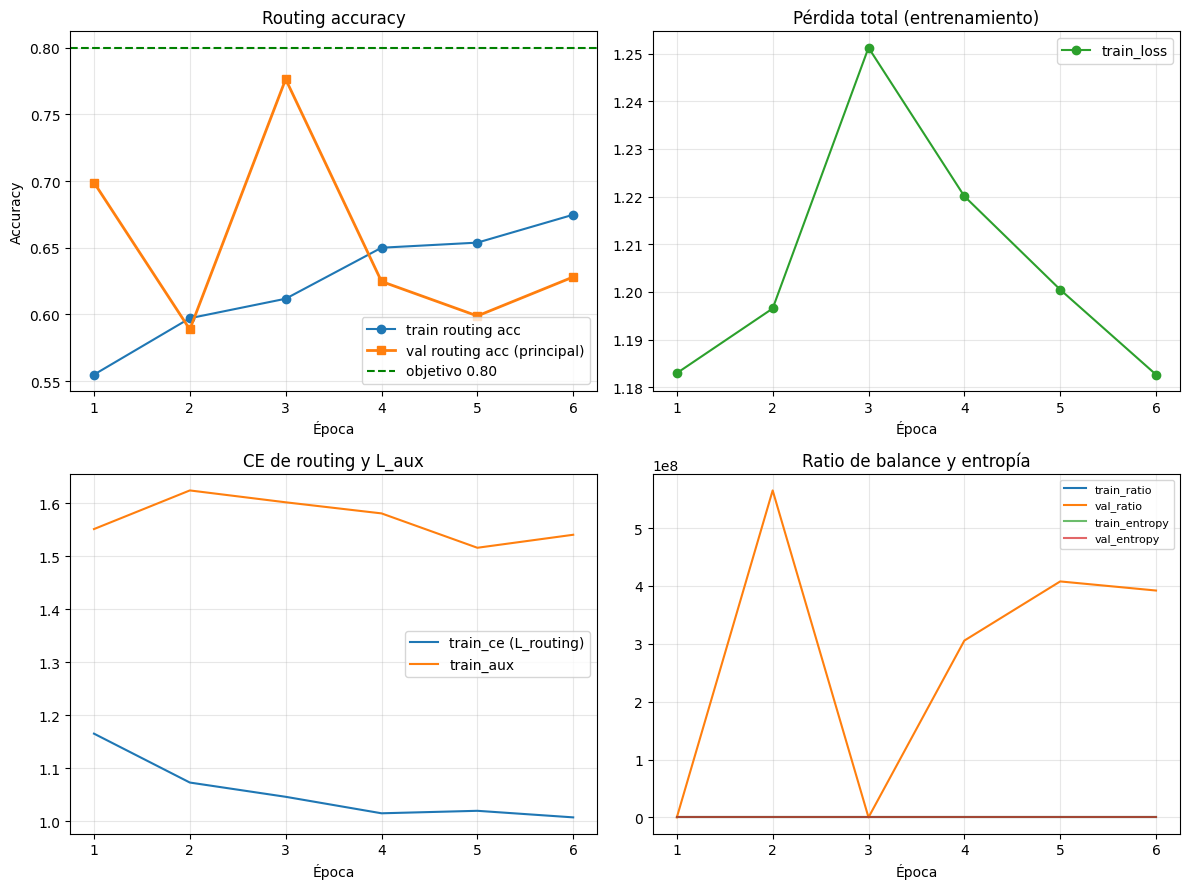


=== Métrica principal (última época) ===
Val routing accuracy: 0.6281  |  Objetivo > 0.80: NO


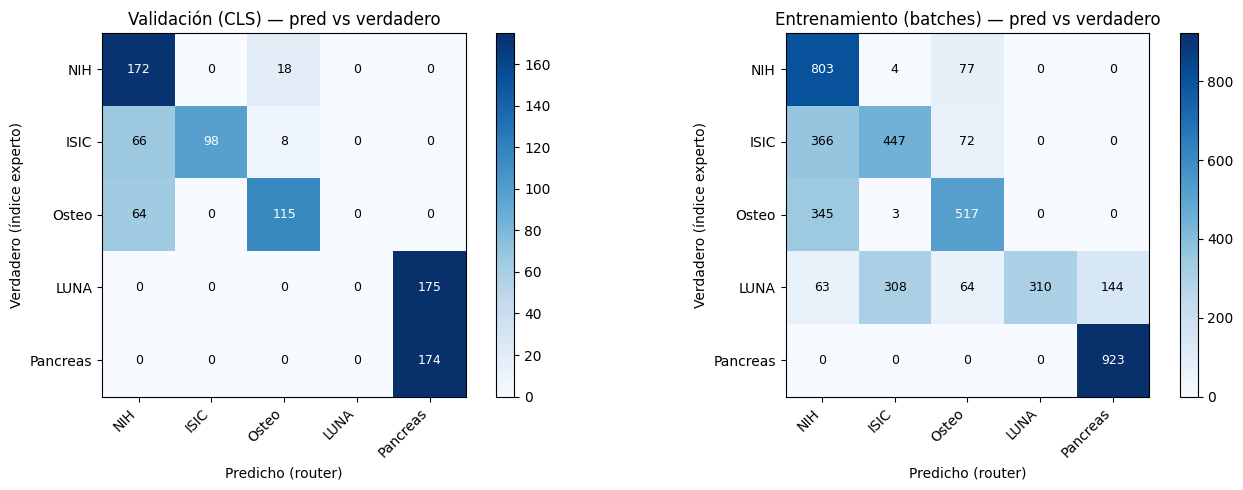

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import torch

if "history_prof" not in globals() or history_prof is None:
    raise RuntimeError("Ejecuta antes la celda con fit_router_with_eval.")

epochs = [h["epoch"] for h in history_prof]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.plot(epochs, [h["train_acc"] for h in history_prof], "o-", label="train routing acc")
ax.plot(epochs, [h["val_acc"] for h in history_prof], "s-", linewidth=2, label="val routing acc (principal)")
ax.axhline(0.80, color="green", linestyle="--", label="objetivo 0.80")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy")
ax.set_title("Routing accuracy")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(epochs, [h["train_loss"] for h in history_prof], "o-", color="C2", label="train_loss")
ax.set_xlabel("Época")
ax.set_title("Pérdida total (entrenamiento)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(epochs, [h["train_ce"] for h in history_prof], label="train_ce (L_routing)")
ax.plot(epochs, [h["train_aux"] for h in history_prof], label="train_aux")
ax.set_xlabel("Época")
ax.set_title("CE de routing y L_aux")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(epochs, [h["train_ratio"] for h in history_prof], label="train_ratio")
ax.plot(epochs, [h["val_ratio"] for h in history_prof], label="val_ratio")
ax.plot(epochs, [h["train_entropy"] for h in history_prof], alpha=0.7, label="train_entropy")
ax.plot(epochs, [h["val_entropy"] for h in history_prof], alpha=0.7, label="val_entropy")
ax.set_xlabel("Época")
ax.set_title("Ratio de balance y entropía")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

last = history_prof[-1]
vacc = last["val_acc"]
ok80 = "SÍ" if vacc >= 0.80 else "NO"
print("\n=== Métrica principal (última época) ===")
print(f"Val routing accuracy: {vacc:.4f}  |  Objetivo > 0.80: {ok80}")


def _to_numpy(cm):
    if isinstance(cm, torch.Tensor):
        return cm.detach().cpu().numpy()
    return np.asarray(cm)


labels = ["NIH", "ISIC", "Osteo", "LUNA", "Pancreas"]
val_cm = _to_numpy(last["val_cm"])
tr_cm = _to_numpy(last["train_cm"])

fig2, (axv, axt) = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title in [
    (axv, val_cm, "Validación (CLS) — pred vs verdadero"),
    (axt, tr_cm, "Entrenamiento (batches) — pred vs verdadero"),
]:
    im = ax.imshow(mat, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_ylabel("Verdadero (índice experto)")
    ax.set_xlabel("Predicho (router)")
    vmax = float(mat.max()) if mat.size else 1.0
    for i in range(5):
        for j in range(5):
            ax.text(
                j,
                i,
                str(int(mat[i, j])),
                ha="center",
                va="center",
                color="w" if mat[i, j] > vmax / 2 else "k",
                fontsize=9,
            )
plt.tight_layout()
plt.show()


## Grad-CAM del router (atención sobre parches)

Mapa tipo **Grad-CAM** sobre la salida del **último bloque ViT** (antes de `router_head`): tres ejemplos **NIH (2D), ISIC (2D), LUNA16 (3D)**. Ejecuta tras tener `router` entrenado/cargado.


IndexError: list index out of range

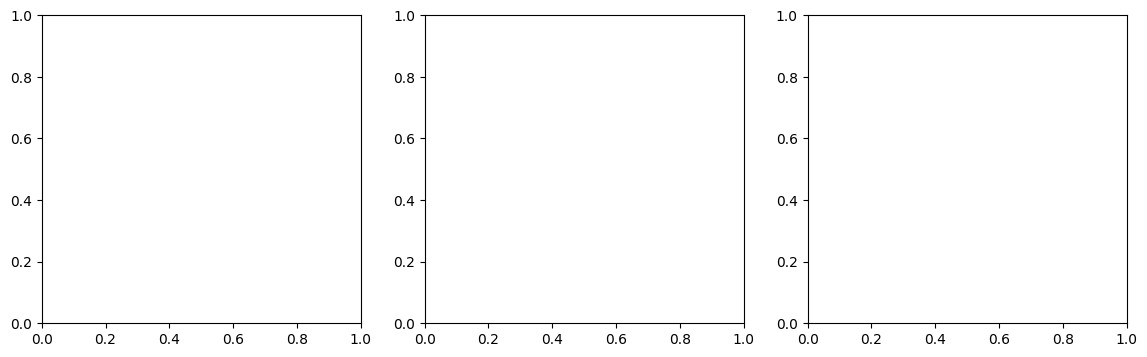

In [20]:
# --- Grad-CAM (último bloque ViT del router): 3 modalidades distintas ---
# Requiere: router, DEVICE, DATASET_ROOTS, preprocessor, scan_dataset_files ya definidos.

import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


def router_gradcam_last_block(router, batch_1sample, device, target_class=None):
    """Grad-CAM tipo token: (grad ⊙ act) sobre la salida del último bloque ViT."""
    router.eval()
    blk = router.vit.blocks[-1]
    acts, grads = [], []

    def fh(m, inp, out):
        acts.append(out)

    def bh(m, gi, go):
        grads.append(go[0])

    h1 = blk.register_forward_hook(fh)
    h2 = blk.register_full_backward_hook(bh)
    dev = torch.device(device)
    batch = [t.to(dev) for t in batch_1sample]
    logits, _ = router(batch)
    if target_class is None:
        target_class = int(logits.argmax(dim=-1).item())
    router.zero_grad(set_to_none=True)
    logits[0, target_class].backward()
    h1.remove()
    h2.remove()
    act, grad = acts[0], grads[0]
    cam = (grad * act).sum(dim=-1).clamp(min=0)
    cam = cam[0, 1:]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
    return cam.detach().cpu(), target_class, probs


def _heatmap_2d(cam1d, nph, npw, out_hw):
    g = cam1d.reshape(nph, npw).float().unsqueeze(0).unsqueeze(0)
    return F.interpolate(g, size=out_hw, mode="bilinear", align_corners=False)[0, 0].numpy()


def _overlay_rgb(tensor_chw, heat_np, alpha=0.45):
    x = tensor_chw.detach().cpu().clamp(0, 1)
    img = x.permute(1, 2, 0).numpy()
    hm = plt.cm.jet(heat_np)[:, :, :3]
    return np.clip((1 - alpha) * img + alpha * hm, 0, 1)


def _middle_slice_3d(vol_chw):
    _, d, h, w = vol_chw.shape
    z = d // 2
    sl = vol_chw[0, z].detach().cpu().numpy()
    sl = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
    rgb = np.stack([sl, sl, sl], axis=-1)
    return rgb, z


def plot_router_gradcam_panel(router, device):
    picks = [
        ("NIH (2D)", "NIH"),
        ("ISIC (2D)", "ISIC"),
        ("LUNA16 (3D)", "LUNA16"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (title, key) in zip(axes, picks):
        root = DATASET_ROOTS.get(key, (None, None))[0]
        if not root or not os.path.isdir(root):
            ax.set_title(f"{title}\n(sin datos)")
            ax.axis("off")
            continue
        files = scan_dataset_files(root)
        if not files:
            ax.set_title(f"{title}\n(sin archivos)")
            ax.axis("off")
            continue
        fpath = files[0]
        t = preprocessor(fpath)
        # 2D: [3,H,W]; 3D: [1,D,H,W] (AdaptivePreprocessor)
        if t.ndim == 3:
            nph, npw = 224 // 16, 224 // 16
            cam, tc, probs = router_gradcam_last_block(router, [t], device)
            expected = nph * npw
            if cam.numel() != expected:
                ax.text(0.1, 0.5, f"Tokens {cam.numel()} != {expected}", transform=ax.transAxes)
                ax.axis("off")
                continue
            hm = _heatmap_2d(cam, nph, npw, (224, 224))
            ov = _overlay_rgb(t, hm)
            ax.imshow(ov)
            pred = int(np.argmax(probs))
            ax.set_title(f"{title}\nargmax exp={pred}  Grad-CAM→exp {tc}\np={probs.round(2)}", fontsize=8)
        elif t.ndim == 4:
            pdim = 64 // 8
            cam, tc, probs = router_gradcam_last_block(router, [t], device)
            expected = pdim ** 3
            if cam.numel() != expected:
                ax.text(0.1, 0.5, f"Tokens {cam.numel()} != {expected}", transform=ax.transAxes)
                ax.axis("off")
                continue
            vol = cam.reshape(pdim, pdim, pdim)
            z = pdim // 2
            sl = vol[:, :, z].numpy()
            sl = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
            rgb_img, _ = _middle_slice_3d(t)
            hm = F.interpolate(
                torch.from_numpy(sl).float().unsqueeze(0).unsqueeze(0),
                size=(64, 64),
                mode="bilinear",
                align_corners=False,
            )[0, 0].numpy()
            ov = np.clip((1 - 0.45) * rgb_img + 0.45 * plt.cm.jet(hm)[:, :, :3], 0, 1)
            ax.imshow(ov)
            pred = int(np.argmax(probs))
            ax.set_title(f"{title}\ncorte axial z={z}\nargmax exp={pred}  CAM→exp {tc}", fontsize=8)
        ax.axis("off")
    fig.suptitle("Grad-CAM (último bloque ViT del router): relevancia por parche hacia la logit objetivo", fontsize=11)
    plt.tight_layout()
    plt.show()


if "router" not in dir() or router is None:
    print("Define `router` entrenado antes de ejecutar esta celda.")
elif "DEVICE" not in dir():
    print("Define DEVICE.")
else:
    plot_router_gradcam_panel(router, DEVICE)

